In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import train_test_split

from statsmodels.tsa.arima.model import ARIMA
from prophet import Prophet
from xgboost import XGBRegressor

import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv(
    "household_power_consumption.txt",
    sep=';',
    low_memory=False,
    na_values=['?']
)

df.head()

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,16/12/2006,17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
1,16/12/2006,17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2,16/12/2006,17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
3,16/12/2006,17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
4,16/12/2006,17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0


In [3]:
df['Datetime'] = pd.to_datetime(
    df['Date'] + ' ' + df['Time'],
    format='%d/%m/%Y %H:%M:%S'
)

df.set_index('Datetime', inplace=True)

df.head()

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
Datetime,,,,,,,,,
2006-12-16 17:24:00,16/12/2006,17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
2006-12-16 17:25:00,16/12/2006,17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2006-12-16 17:26:00,16/12/2006,17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
2006-12-16 17:27:00,16/12/2006,17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
2006-12-16 17:28:00,16/12/2006,17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0


In [4]:
df['Global_active_power'] = pd.to_numeric(
    df['Global_active_power'],
    errors='coerce'
)

df = df[['Global_active_power']]

df.fillna(method='ffill', inplace=True)

df.isnull().sum()

,0
Global_active_power,0


In [5]:
hourly_data = df.resample('H').mean()

hourly_data.head()

,Global_active_power
Datetime,
2006-12-16 17:00:00,4.222889
2006-12-16 18:00:00,3.632200
2006-12-16 19:00:00,3.400233
2006-12-16 20:00:00,3.268567
2006-12-16 21:00:00,3.056467


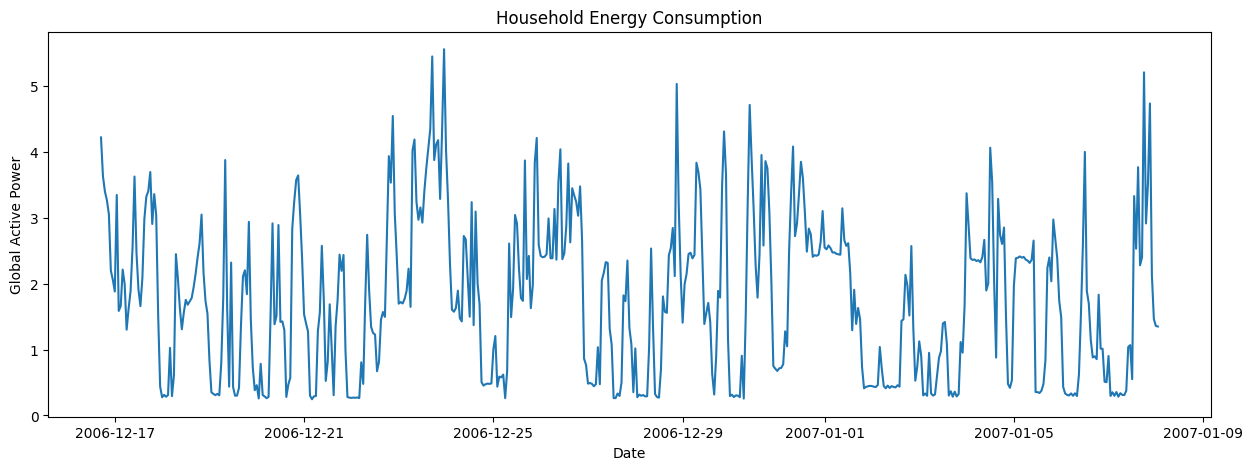

In [6]:
plt.figure(figsize=(15,5))
plt.plot(hourly_data)
plt.title("Household Energy Consumption")
plt.xlabel("Date")
plt.ylabel("Global Active Power")
plt.show()

In [7]:
hourly_data['hour'] = hourly_data.index.hour
hourly_data['dayofweek'] = hourly_data.index.dayofweek
hourly_data['month'] = hourly_data.index.month
hourly_data['weekend'] = hourly_data['dayofweek'].isin([5,6]).astype(int)

hourly_data.head()

,Global_active_power,hour,dayofweek,month,weekend
Datetime,,,,,
2006-12-16 17:00:00,4.222889,17,5,12,1
2006-12-16 18:00:00,3.632200,18,5,12,1
2006-12-16 19:00:00,3.400233,19,5,12,1
2006-12-16 20:00:00,3.268567,20,5,12,1
2006-12-16 21:00:00,3.056467,21,5,12,1


In [8]:
train_size = int(len(hourly_data)*0.8)

train = hourly_data[:train_size]
test = hourly_data[train_size:]

In [9]:
arima_model = ARIMA(
    train['Global_active_power'],
    order=(5,1,0)
)

arima_fit = arima_model.fit()

arima_pred = arima_fit.forecast(
    steps=len(test)
)

arima_mae = mean_absolute_error(
    test['Global_active_power'],
    arima_pred
)

arima_rmse = np.sqrt(
    mean_squared_error(
        test['Global_active_power'],
        arima_pred
    )
)

print("ARIMA MAE:", arima_mae)
print("ARIMA RMSE:", arima_rmse)

ARIMA MAE: 1.0124202231272668
ARIMA RMSE: 1.2175211562072308


In [10]:
prophet_df = hourly_data.reset_index()

prophet_df = prophet_df.rename(
    columns={
        'Datetime':'ds',
        'Global_active_power':'y'
    }
)

split = int(len(prophet_df)*0.8)

train_prophet = prophet_df[:split]
test_prophet = prophet_df[split:]

model = Prophet()

model.fit(train_prophet)

future = model.make_future_dataframe(
    periods=len(test_prophet),
    freq='H'
)

forecast = model.predict(future)

pred_prophet = forecast['yhat'][-len(test_prophet):]

mae_prophet = mean_absolute_error(
    test_prophet['y'],
    pred_prophet
)

rmse_prophet = np.sqrt(
    mean_squared_error(
        test_prophet['y'],
        pred_prophet
    )
)

print("Prophet MAE:", mae_prophet)
print("Prophet RMSE:", rmse_prophet)

INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.


Prophet MAE: 1.221836374876416
Prophet RMSE: 1.4102929844576781


In [11]:
xgb_data = hourly_data.copy()

X = xgb_data.drop(
    'Global_active_power',
    axis=1
)

y = xgb_data['Global_active_power']

X_train = X[:train_size]
X_test = X[train_size:]

y_train = y[:train_size]
y_test = y[train_size:]

xgb = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6
)

xgb.fit(X_train, y_train)

xgb_pred = xgb.predict(X_test)

xgb_mae = mean_absolute_error(
    y_test,
    xgb_pred
)

xgb_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        xgb_pred
    )
)

print("XGBoost MAE:", xgb_mae)
print("XGBoost RMSE:", xgb_rmse)

XGBoost MAE: 1.297122495956491
XGBoost RMSE: 1.5252574268769938


In [12]:
results = pd.DataFrame({
    'Model':['ARIMA','Prophet','XGBoost'],
    'MAE':[arima_mae,mae_prophet,xgb_mae],
    'RMSE':[arima_rmse,rmse_prophet,xgb_rmse]
})

results.sort_values('RMSE')

,Model,MAE,RMSE
0,ARIMA,1.012420,1.217521
1,Prophet,1.221836,1.410293
2,XGBoost,1.297122,1.525257


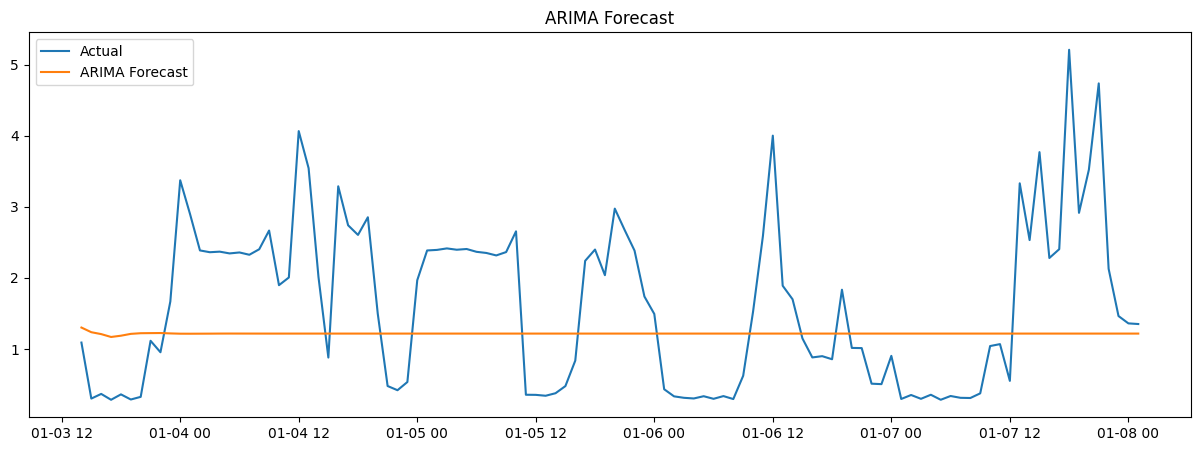

In [13]:
plt.figure(figsize=(15,5))

plt.plot(
    test.index,
    test['Global_active_power'],
    label='Actual'
)

plt.plot(
    test.index,
    arima_pred,
    label='ARIMA Forecast'
)

plt.legend()
plt.title("ARIMA Forecast")
plt.show()

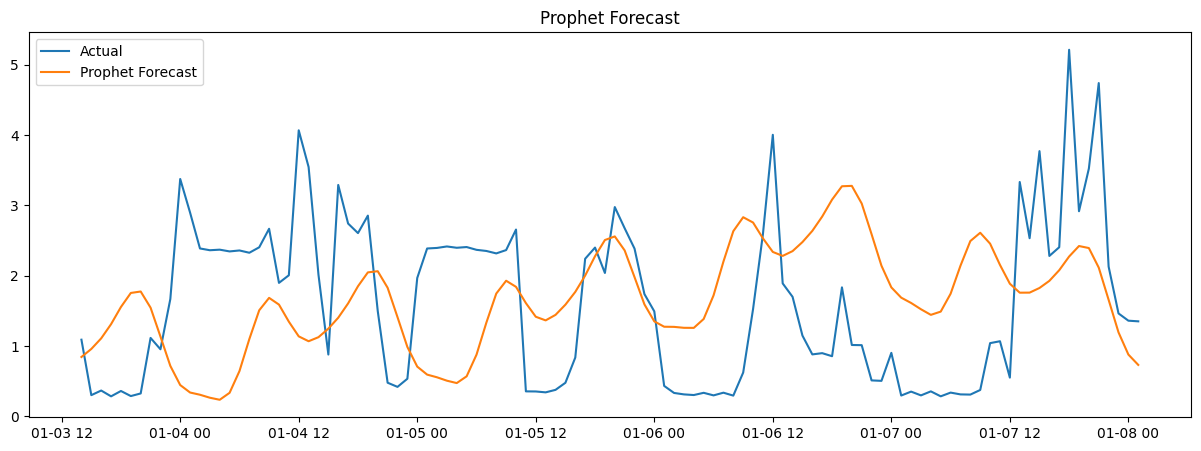

In [14]:
plt.figure(figsize=(15,5))

plt.plot(
    test_prophet['ds'],
    test_prophet['y'],
    label='Actual'
)

plt.plot(
    test_prophet['ds'],
    pred_prophet,
    label='Prophet Forecast'
)

plt.legend()
plt.title("Prophet Forecast")
plt.show()

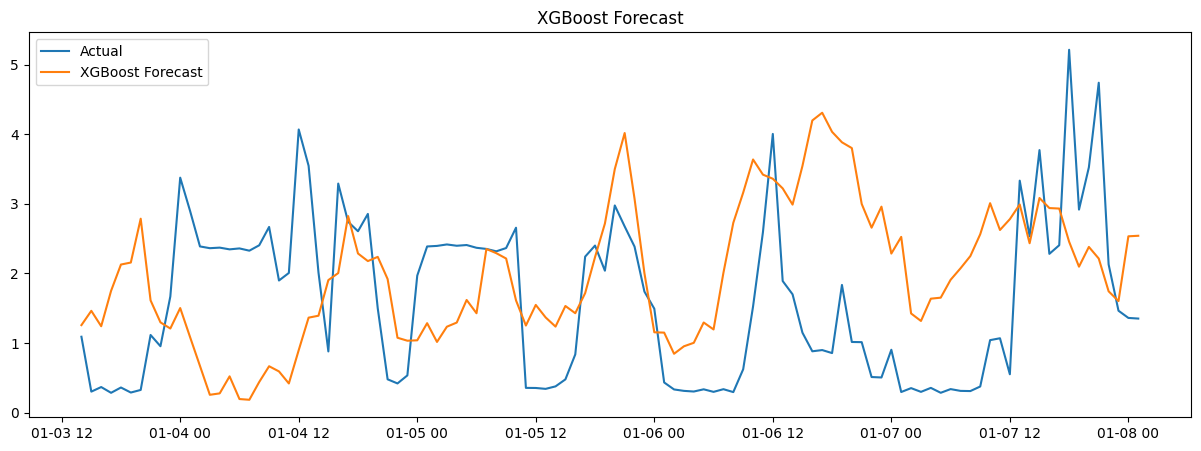

In [15]:
plt.figure(figsize=(15,5))

plt.plot(
    y_test.index,
    y_test,
    label='Actual'
)

plt.plot(
    y_test.index,
    xgb_pred,
    label='XGBoost Forecast'
)

plt.legend()
plt.title("XGBoost Forecast")
plt.show()